In [ ]:
# Figure generation of GO enriched categories for OHBM 2026 abstract

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ej_df = pd.read_csv('../data/erminej_out.csv')
display(ej_df.head())

,ID,Name,p val,p-adj,MFPvalue,CorrectedMFPvalue,Multifunctionality,Category
0,GO:0098815,modulation of excitatory postsynaptic potential,1.000000e-12,5.790000e-09,1.000000e-12,5.790000e-09,0.904000,Synaptic function
1,GO:0002181,cytoplasmic translation,5.000000e-06,1.447750e-02,5.000000e-06,1.447750e-02,0.000766,Ribosomal function
2,GO:0022626,cytosolic ribosome,5.000000e-06,9.650000e-03,1.000000e-05,1.930333e-02,0.001670,Ribosomal function
3,GO:2000463,positive regulation of excitatory postsynaptic...,2.500000e-05,3.619375e-02,1.500000e-05,2.171625e-02,0.867000,Synaptic function
4,GO:0060079,excitatory postsynaptic potential,8.000000e-05,9.265600e-02,1.350000e-04,1.563570e-01,0.911000,Synaptic function


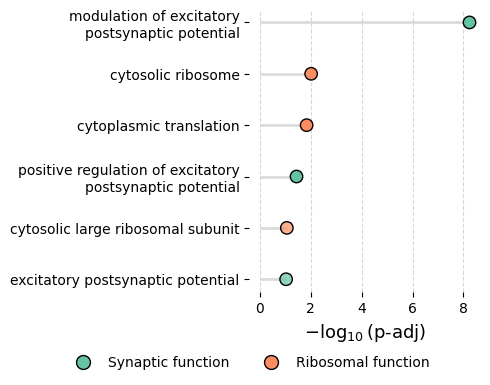

In [3]:
import textwrap
import matplotlib.colors as mcolors

# Filter and compute -log10(p-adj)
ej_df = ej_df[ej_df['p-adj'] < 0.1]
ej_df['-log10(p-adj)'] = -np.log10(ej_df['p-adj'])

# Sort for visualization (ascending so smallest at top when plotting with y increasing)
ej_df_sorted = ej_df.sort_values('-log10(p-adj)', ascending=True)

# Wrap long names
wrap_width = 35  # adjust width to control where names break
ej_df_sorted['Name_wrapped'] = ej_df_sorted['Name'].astype(str).apply(lambda s: '\n'.join(textwrap.wrap(s, wrap_width)))

# Map categories to colors
categories = ej_df_sorted['Category'].unique()
palette = sns.color_palette('Set2', len(categories))
category2color = dict(zip(categories, palette))

# Per-point alpha based on significance threshold
alpha_vals = np.where(ej_df_sorted['p-adj'] < 0.05, 1.0, 0.7)

# Build RGBA colors per point by combining base color and per-point alpha
rgba_colors = [
    mcolors.to_rgba(category2color[cat], alpha=alpha)
    for cat, alpha in zip(ej_df_sorted['Category'], alpha_vals)
]

# Numeric y positions and labels
y_pos = np.arange(len(ej_df_sorted))
y_labels = ej_df_sorted['Name_wrapped'].values

fig, ax = plt.subplots(figsize=(5, max(4, len(ej_df_sorted) * 0.15)))

# Plot light gray horizontal lines from 0 to -log10(p-adj)
ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=ej_df_sorted['-log10(p-adj)'],
    color='lightgray',
    alpha=0.8,
    linewidth=2,
)

# Scatter with RGBA colors (no scalar alpha kwarg)
sc = ax.scatter(
    ej_df_sorted['-log10(p-adj)'],
    y_pos,
    c=rgba_colors,
    s=80,
    edgecolor='black',
    zorder=3,
)

# Set y ticks to wrapped names
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)

ax.set_xlabel(r'$-\log_{10}(\mathrm{p\text{-}adj})$', fontsize=13)
ax.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine(left=True, bottom=True)

# Create custom legend using base category colors (fully opaque markers)
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=cat,
               markerfacecolor=col, markersize=10, markeredgecolor='black')
    for cat, col in category2color.items()
]
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0, -0.18), ncol=2, frameon=False)

plt.tight_layout()
plt.savefig('../results/erminej_enrichment_plot.svg', bbox_inches='tight')

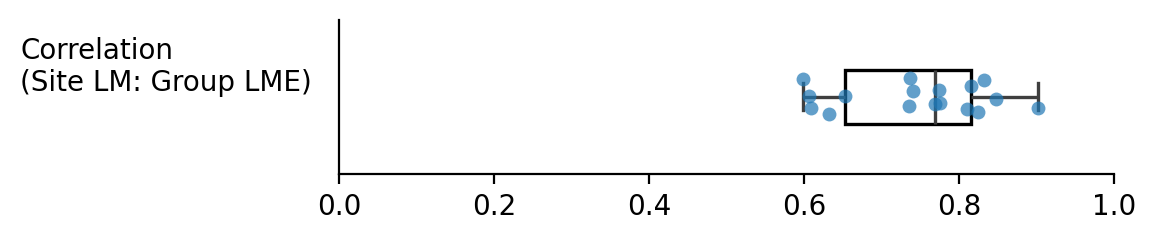

In [48]:
lme_corr = pd.read_csv('../data/correlation_df.csv')
fig, ax = plt.subplots(1, 1, figsize=(5, 1), dpi=200)
sns.boxplot(
    data=lme_corr,
    x='correlation',
    ax=ax,
    width=0.35,
    orient='h',
    fliersize=0,          # avoid duplicate points (shown by scatter)
    linewidth=1.2,
    boxprops=dict(edgecolor='black', facecolor='none'),
)

sns.stripplot(
    data=lme_corr,
    x='correlation',   # horizontal
    ax=ax,
    orient='h',
    color='tab:blue',
    size=5,
    jitter=0.12,
    alpha=0.7,
)
ax.set_xlim(0, 1)
ax.set_xlabel('', fontsize=12)
ax.set_yticks([])
ax.set_ylabel('Correlation\n(Site LM: Group LME)', rotation=0, labelpad=115, ha='left')
sns.despine(ax=ax)
plt.savefig('../results/lme_correlation_boxplot.svg', bbox_inches='tight')